# Week 2 · Day 4 — 训练循环 + Loss 曲线监控

$$\mathcal{L} = 0.5 \times BCE + 0.5 \times Dice$$

训练完成后另开终端查看 TensorBoard：
```bash
tensorboard --logdir ../results/week2_runs/tb_logs
```

In [2]:
import matplotlib
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

import sys, time, yaml
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from peft import LoraConfig, get_peft_model, TaskType

MODEL_DIR  = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\prithvi_100m')
PATCH_DIR  = Path(r'D:\geology AI\data\processed\week2_patches')
RUN_DIR    = Path(r'D:\geology AI\results\week2_runs')
FIG_DIR    = Path(r'D:\geology AI\results\figures')
RUN_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(MODEL_DIR))
from prithvi_mae import PrithviMAE

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP    = torch.cuda.is_available()
print(f'设备: {DEVICE}  AMP: {AMP}')

EPOCHS     = 30
LR         = 3e-4
BATCH_SIZE = 4
LORA_R     = 8
POS_WEIGHT = 3.92

MEAN = np.array([343.4, 546.8, 444.1, 2942.5, 1444.6, 899.7], dtype=np.float32)
STD  = np.array([255.0, 340.6, 373.0, 1232.4,  852.0, 680.1], dtype=np.float32)

c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


设备: cuda  AMP: True


## 4.1 Dataset + Model（复用 Day 2/3 定义）

In [4]:
class ErosionDataset(Dataset):
    def __init__(self, patch_dir, augment=True):
        self.patch_dir = Path(patch_dir)
        self.augment = augment
        self.indices = sorted(
            int(p.stem.split('_')[1]) for p in self.patch_dir.glob('img_*.npy'))
        assert len(self.indices) > 0
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img  = np.load(self.patch_dir / f'img_{i:04d}.npy').astype(np.float32)
        mask = np.load(self.patch_dir / f'mask_{i:04d}.npy').astype(np.float32)
        img  = (img - MEAN[:, None, None]) / STD[:, None, None]
        if self.augment:
            if np.random.rand() > .5: img=img[:,:,::-1].copy(); mask=mask[:,::-1].copy()
            if np.random.rand() > .5: img=img[:,::-1,:].copy(); mask=mask[::-1,:].copy()
        return torch.from_numpy(img), torch.from_numpy(mask).unsqueeze(0)

class SegDecoder(nn.Module):
    def __init__(self, e=768):
        super().__init__()
        self.up1  = nn.Sequential(nn.ConvTranspose2d(e,256,2,2),   nn.BatchNorm2d(256), nn.GELU())
        self.up2  = nn.Sequential(nn.ConvTranspose2d(256,64,4,4),  nn.BatchNorm2d(64),  nn.GELU())
        self.up3  = nn.Sequential(nn.ConvTranspose2d(64,32,2,2),   nn.BatchNorm2d(32),  nn.GELU())
        self.head = nn.Conv2d(32, 1, 1)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')  # ← 关键字参数
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x): return self.head(self.up3(self.up2(self.up1(x))))

class PrithviSegModel(nn.Module):
    NUM_FRAMES = 3; EMBED_DIM = 768; GRID_SIZE = 14
    def __init__(self, prithvi_model):
        super().__init__()
        self.prithvi = prithvi_model
        self.decoder = SegDecoder()
    def forward(self, x):
        B = x.shape[0]
        x_t = x.unsqueeze(2).repeat(1, 1, self.NUM_FRAMES, 1, 1)
        tokens = self.prithvi.base_model.model.forward_features(x_t)[-1]
        tokens = tokens[:, 1:, :].reshape(
            B, self.NUM_FRAMES, self.GRID_SIZE**2, self.EMBED_DIM).mean(1)
        feat = tokens.transpose(1, 2).reshape(
            B, self.EMBED_DIM, self.GRID_SIZE, self.GRID_SIZE)
        return self.decoder(feat)

# 数据
full_ds = ErosionDataset(PATCH_DIR)
n_val   = max(1, int(len(full_ds) * .2))
train_ds, val_ds = random_split(full_ds, [len(full_ds)-n_val, n_val],
                                generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train={len(train_ds)}  Val={len(val_ds)}')

# 模型
ckpt = torch.load(MODEL_DIR / 'Prithvi_100M.pt', map_location='cpu')
state_dict = ckpt
embed_dim         = state_dict['encoder.norm.weight'].shape[0]
decoder_embed_dim = state_dict['decoder.decoder_embed.bias'].shape[0]
num_heads         = embed_dim // 64

prithvi = PrithviMAE(
    img_size=224, patch_size=16, num_frames=3, tubelet_size=1, in_chans=6,
    embed_dim=embed_dim, depth=12, num_heads=num_heads,
    decoder_embed_dim=decoder_embed_dim, decoder_depth=8, decoder_num_heads=16,
    mlp_ratio=4.0, norm_pix_loss=False,
)
prithvi.load_state_dict(state_dict, strict=False)

model = PrithviSegModel(prithvi)
model.prithvi = get_peft_model(prithvi, LoraConfig(
    r=LORA_R, lora_alpha=LORA_R*2, lora_dropout=0.1, bias='none',
    target_modules=['qkv', 'proj'], task_type=TaskType.FEATURE_EXTRACTION
))
model = model.to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'可训练参数: {trainable/1e6:.2f}M')

Train=160  Val=40
可训练参数: 1.72M


## 4.2 Loss 函数 + 指标

In [5]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_w=0.5, smooth=1.0, pos_weight=None):
        super().__init__(); self.bce_w=bce_w; self.smooth=smooth; self.pw=pos_weight
    def forward(self,logits,targets):
        pw=None if self.pw is None else torch.tensor([self.pw],device=logits.device)
        bce=F.binary_cross_entropy_with_logits(logits,targets,pos_weight=pw)
        p=torch.sigmoid(logits)
        i=(p*targets).sum((2,3)); u=p.sum((2,3))+targets.sum((2,3))
        dice=(1-(2*i+self.smooth)/(u+self.smooth)).mean()
        return self.bce_w*bce+(1-self.bce_w)*dice, bce.item(), dice.item()

def iou_score(logits,targets,th=0.5):
    p=(torch.sigmoid(logits)>th).float()
    i=(p*targets).sum((2,3)); u=p.sum((2,3))+targets.sum((2,3))-i
    return ((i+1e-6)/(u+1e-6)).mean().item()

def f1_score(logits,targets,th=0.5):
    p=(torch.sigmoid(logits)>th).float()
    tp=(p*targets).sum((2,3)); fp=(p*(1-targets)).sum((2,3)); fn=((1-p)*targets).sum((2,3))
    return ((2*tp+1e-6)/(2*tp+fp+fn+1e-6)).mean().item()

criterion = BCEDiceLoss(bce_w=0.5, pos_weight=POS_WEIGHT)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler(enabled=AMP)
writer    = SummaryWriter(str(RUN_DIR / 'tb_logs'))
print('优化器配置完成')

优化器配置完成


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_27368\727442544.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=AMP)


## 4.3 训练主循环

In [6]:
def train_epoch(model,loader,optimizer,criterion,scaler,device,epoch,writer):
    model.train(); losses,ious=[],[]
    for i,(imgs,masks) in enumerate(loader):
        imgs=imgs.to(device,non_blocking=True); masks=masks.to(device,non_blocking=True)
        optimizer.zero_grad()
        with autocast(enabled=AMP):
            logits=model(imgs); loss,_,_=criterion(logits,masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad],1.0)
        scaler.step(optimizer); scaler.update()
        losses.append(loss.item()); ious.append(iou_score(logits.detach(),masks))
        writer.add_scalar('train/loss_step',loss.item(),epoch*len(loader)+i)
    return np.mean(losses),np.mean(ious)

@torch.no_grad()
def validate(model,loader,criterion,device):
    model.eval(); losses,ious,f1s=[],[],[]
    for imgs,masks in loader:
        imgs=imgs.to(device,non_blocking=True); masks=masks.to(device,non_blocking=True)
        with autocast(enabled=AMP): logits=model(imgs); loss,_,_=criterion(logits,masks)
        losses.append(loss.item()); ious.append(iou_score(logits,masks)); f1s.append(f1_score(logits,masks))
    return np.mean(losses),np.mean(ious),np.mean(f1s)

BEST_PATH = RUN_DIR / 'best_model.pt'
best_iou  = 0.0
tr_losses,vl_losses,tr_ious,vl_ious=[],[],[],[]

print(f'开始训练  epochs={EPOCHS}  batch={BATCH_SIZE}  lr={LR}\n')
for epoch in range(EPOCHS):
    t0=time.time()
    trl,tri=train_epoch(model,train_loader,optimizer,criterion,scaler,DEVICE,epoch,writer)
    vll,vli,vlf=validate(model,val_loader,criterion,DEVICE)
    scheduler.step()
    tr_losses.append(trl); vl_losses.append(vll)
    tr_ious.append(tri);   vl_ious.append(vli)
    writer.add_scalars('loss',{'train':trl,'val':vll},epoch)
    writer.add_scalars('iou', {'train':tri,'val':vli}, epoch)
    writer.add_scalar('val/f1',vlf,epoch)
    writer.add_scalar('lr',scheduler.get_last_lr()[0],epoch)
    flag=''
    if vli>best_iou:
        best_iou=vli
        torch.save({'epoch':epoch,'val_iou':vli,'val_f1':vlf,'model_state':model.state_dict()},BEST_PATH)
        flag='  ★ best'
    print(f'E{epoch+1:3d}/{EPOCHS}  '
          f'tr_loss={trl:.4f} tr_iou={tri:.4f}  '
          f'vl_loss={vll:.4f} vl_iou={vli:.4f} f1={vlf:.4f}  '
          f'{time.time()-t0:.0f}s{flag}')

writer.close()
print(f'\n✓ 训练完成  最佳 Val IoU = {best_iou:.4f}')

开始训练  epochs=30  batch=4  lr=0.0003



C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_27368\759933752.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=AMP):
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_27368\759933752.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=AMP): logits=model(imgs); loss,_,_=criterion(logits,masks)


E  1/30  tr_loss=0.7754 tr_iou=0.3716  vl_loss=0.5760 vl_iou=0.4941 f1=0.6516  4s  ★ best
E  2/30  tr_loss=0.5573 tr_iou=0.4753  vl_loss=0.5145 vl_iou=0.5210 f1=0.6760  3s  ★ best
E  3/30  tr_loss=0.5070 tr_iou=0.5056  vl_loss=0.4813 vl_iou=0.5551 f1=0.7033  3s  ★ best
E  4/30  tr_loss=0.4828 tr_iou=0.5266  vl_loss=0.4699 vl_iou=0.5409 f1=0.6929  3s
E  5/30  tr_loss=0.4551 tr_iou=0.5435  vl_loss=0.4393 vl_iou=0.5697 f1=0.7172  3s  ★ best
E  6/30  tr_loss=0.4492 tr_iou=0.5530  vl_loss=0.4378 vl_iou=0.5755 f1=0.7206  3s  ★ best
E  7/30  tr_loss=0.4269 tr_iou=0.5646  vl_loss=0.4303 vl_iou=0.5633 f1=0.7137  3s
E  8/30  tr_loss=0.4197 tr_iou=0.5702  vl_loss=0.4100 vl_iou=0.5839 f1=0.7299  3s  ★ best
E  9/30  tr_loss=0.4200 tr_iou=0.5721  vl_loss=0.4185 vl_iou=0.6043 f1=0.7455  3s  ★ best
E 10/30  tr_loss=0.4198 tr_iou=0.5763  vl_loss=0.4000 vl_iou=0.5979 f1=0.7412  3s
E 11/30  tr_loss=0.3996 tr_iou=0.5872  vl_loss=0.3948 vl_iou=0.5902 f1=0.7356  3s
E 12/30  tr_loss=0.3941 tr_iou=0.5908  vl_

## 4.4 训练曲线

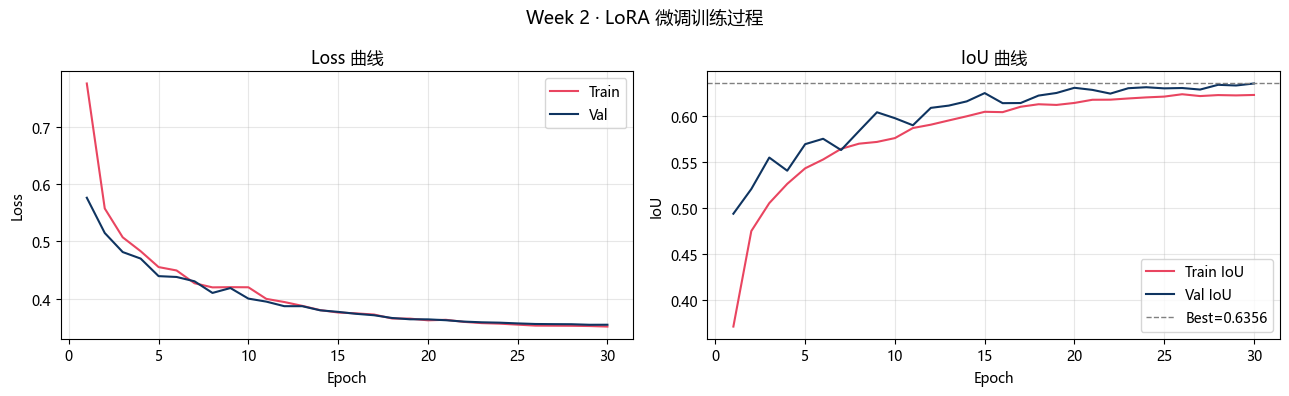

图已保存


In [7]:
ep=range(1,len(tr_losses)+1)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4))
ax1.plot(ep,tr_losses,label='Train',color='#e94560',lw=1.5)
ax1.plot(ep,vl_losses,label='Val',  color='#0f3460',lw=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss 曲线'); ax1.legend(); ax1.grid(alpha=.3)
ax2.plot(ep,tr_ious,label='Train IoU',color='#e94560',lw=1.5)
ax2.plot(ep,vl_ious,label='Val IoU',  color='#0f3460',lw=1.5)
ax2.axhline(best_iou,color='gray',ls='--',lw=1,label=f'Best={best_iou:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU'); ax2.set_title('IoU 曲线'); ax2.legend(); ax2.grid(alpha=.3)
plt.suptitle('Week 2 · LoRA 微调训练过程',fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR/'week2_08_training_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('图已保存')

---
## 💾 保存到 GitHub

In [8]:
import subprocess, os
from pathlib import Path

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/08_training.ipynb')
git('git add results/figures/week2_08_training_curves.png')

msg = f'Week2 Day4: LoRA training 30ep, best_val_iou={best_iou:.4f}'
git(f'git commit -m "{msg}"')
git('git push origin main')
print('\n✓ 已推送到 GitHub')

[main 832d23a] Week2 Day4: LoRA training 30ep, best_val_iou=0.6356
 2 files changed, 314 insertions(+)
 create mode 100644 notebooks/08_training.ipynb
 create mode 100644 results/figures/week2_08_training_curves.png
To https://github.com/lofophil/geo-foundation-experiments.git
   1dd7432..832d23a  main -> main

✓ 已推送到 GitHub
